## Setup

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import unittest

DATA_PATH = "Lab Session Data.xlsx"  # update path if needed (e.g. /content/... in Colab)
df = pd.read_excel(DATA_PATH, sheet_name="marketing_campaign")
df = df.dropna(subset=["Income"]).reset_index(drop=True)
print(df.shape)
df.head()

(2216, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-04-09 00:00:00,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-08-03 00:00:00,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-10-02 00:00:00,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


## A1. Repeat Lab 03 experiments using AI tools


In [6]:
# ==========================================================
# A1 - Modular functions (Lab 03 experiments, repeated with AI-tool assistance)
# Generated using: Claude (Anthropic)
# ==========================================================

def identify_feature_types(df):
    """Nominal / Ordinal / Interval / Ratio classification for marketing_campaign columns."""
    feature_types = {
        "ID": "Nominal", "Year_Birth": "Interval", "Education": "Ordinal",
        "Marital_Status": "Nominal", "Income": "Ratio", "Kidhome": "Ratio",
        "Teenhome": "Ratio", "Dt_Customer": "Interval", "Recency": "Ratio",
        "MntWines": "Ratio", "MntFruits": "Ratio", "MntMeatProducts": "Ratio",
        "MntFishProducts": "Ratio", "MntSweetProducts": "Ratio", "MntGoldProds": "Ratio",
        "NumDealsPurchases": "Ratio", "NumWebPurchases": "Ratio", "NumCatalogPurchases": "Ratio",
        "NumStorePurchases": "Ratio", "NumWebVisitsMonth": "Ratio", "AcceptedCmp3": "Nominal",
        "AcceptedCmp4": "Nominal", "AcceptedCmp5": "Nominal", "AcceptedCmp1": "Nominal",
        "AcceptedCmp2": "Nominal", "Complain": "Nominal", "Z_CostContact": "Ratio",
        "Z_Revenue": "Ratio", "Response": "Nominal",
    }
    return feature_types


def label_encode(series):
    """Label-encode a categorical pandas Series. Returns (encoded_array, mapping_dict)."""
    categories = sorted(series.dropna().unique().tolist())
    mapping = {cat: idx for idx, cat in enumerate(categories)}
    encoded = series.map(mapping).to_numpy()
    return encoded, mapping


def one_hot_encode(series):
    """One-hot encode a categorical pandas Series. Returns (encoded_matrix, category_list)."""
    categories = sorted(series.dropna().unique().tolist())
    n, k = len(series), len(categories)
    encoded = np.zeros((n, k), dtype=int)
    cat_to_idx = {cat: idx for idx, cat in enumerate(categories)}
    for row_idx, val in enumerate(series.to_numpy()):
        if pd.isna(val):
            continue
        encoded[row_idx, cat_to_idx[val]] = 1
    return encoded, categories


def minkowski_distance(vec_a, vec_b, p):
    """Generalized Minkowski distance. p=1 -> Manhattan, p=2 -> Euclidean."""
    vec_a, vec_b = np.asarray(vec_a, dtype=float), np.asarray(vec_b, dtype=float)
    return float(np.sum(np.abs(vec_a - vec_b) ** p) ** (1.0 / p))


def dot_product(vec_a, vec_b):
    """Dot product without using numpy.dot."""
    vec_a, vec_b = np.asarray(vec_a, dtype=float), np.asarray(vec_b, dtype=float)
    total = 0.0
    for x, y in zip(vec_a, vec_b):
        total += x * y
    return total


def vector_norm(vec):
    """Euclidean norm without using numpy.linalg.norm."""
    vec = np.asarray(vec, dtype=float)
    total = 0.0
    for x in vec:
        total += x * x
    return total ** 0.5


def compute_mean(data):
    data = np.asarray(data, dtype=float)
    return sum(data) / len(data)


def compute_variance(data):
    data = np.asarray(data, dtype=float)
    mu = compute_mean(data)
    return sum((x - mu) ** 2 for x in data) / len(data)


def compute_std(data):
    return compute_variance(data) ** 0.5


def kmeans(data, k, max_iters=100, seed=1):
    """K-means, own implementation (explicit loops), Algorithm 8.1 (Tan/Steinbach/Kumar)."""
    data = np.asarray(data, dtype=float)
    n, d = data.shape
    rng = np.random.default_rng(seed)
    centroids = data[rng.choice(n, k, replace=False)].copy()
    labels = np.zeros(n, dtype=int)

    for it in range(max_iters):
        new_labels = np.zeros(n, dtype=int)
        for i in range(n):
            best_c, best_d = 0, None
            for c in range(k):
                dist = sum((data[i, f] - centroids[c, f]) ** 2 for f in range(d)) ** 0.5
                if best_d is None or dist < best_d:
                    best_d, best_c = dist, c
            new_labels[i] = best_c

        new_centroids = np.zeros((k, d))
        for c in range(k):
            pts = data[new_labels == c]
            new_centroids[c] = pts.mean(axis=0) if len(pts) > 0 else centroids[c]

        if np.array_equal(new_labels, labels) and it > 0:
            labels, centroids = new_labels, new_centroids
            break
        labels, centroids = new_labels, new_centroids

    return labels, centroids


def inertia(data, labels, centroids):
    data = np.asarray(data, dtype=float)
    return sum(np.sum((data[i] - centroids[labels[i]]) ** 2) for i in range(len(data)))

print("A1 functions defined.")

A1 functions defined.


Feature types:
  ID                     -> Nominal
  Year_Birth             -> Interval
  Education              -> Ordinal
  Marital_Status         -> Nominal
  Income                 -> Ratio
  Kidhome                -> Ratio
  Teenhome               -> Ratio
  Dt_Customer            -> Interval
  Recency                -> Ratio
  MntWines               -> Ratio
  MntFruits              -> Ratio
  MntMeatProducts        -> Ratio
  MntFishProducts        -> Ratio
  MntSweetProducts       -> Ratio
  MntGoldProds           -> Ratio
  NumDealsPurchases      -> Ratio
  NumWebPurchases        -> Ratio
  NumCatalogPurchases    -> Ratio
  NumStorePurchases      -> Ratio
  NumWebVisitsMonth      -> Ratio
  AcceptedCmp3           -> Nominal
  AcceptedCmp4           -> Nominal
  AcceptedCmp5           -> Nominal
  AcceptedCmp1           -> Nominal
  AcceptedCmp2           -> Nominal
  Complain               -> Nominal
  Z_CostContact          -> Ratio
  Z_Revenue              -> Ratio
  Respons

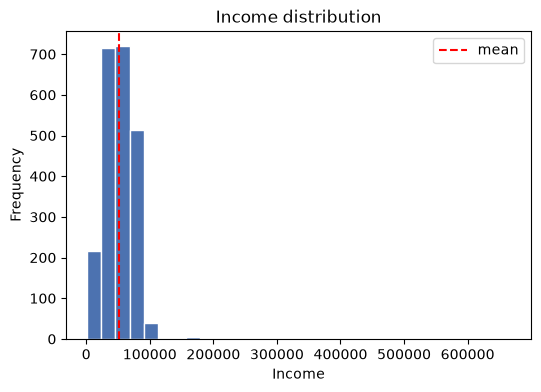

In [7]:
# --- A1 driver: run the experiments and print results ---

feature_types = identify_feature_types(df)
print("Feature types:")
for col, t in feature_types.items():
    print(f"  {col:22s} -> {t}")

enc_edu, mapping_edu = label_encode(df["Education"])
enc_marital, cats_marital = one_hot_encode(df["Marital_Status"])
print(f"\nEducation label mapping: {mapping_edu}")
print(f"Marital_Status categories (one-hot): {cats_marital}")

numeric_cols = ["Income", "Recency", "MntWines", "MntFruits", "MntMeatProducts",
                "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
vec_a = df.loc[0, numeric_cols].to_numpy(dtype=float)
vec_b = df.loc[1, numeric_cols].to_numpy(dtype=float)

from scipy.spatial.distance import minkowski as scipy_minkowski
print("\nMinkowski distance, own vs scipy, p=1..10:")
for p in range(1, 11):
    own, ref = minkowski_distance(vec_a, vec_b, p), scipy_minkowski(vec_a, vec_b, p)
    print(f"  p={p:2d}: own={own:.4f}  scipy={ref:.4f}  diff={abs(own-ref):.2e}")

print(f"\nDot product: own={dot_product(vec_a, vec_b):.4f}  numpy={np.dot(vec_a, vec_b):.4f}")
print(f"Norm: own={vector_norm(vec_a):.4f}  numpy={np.linalg.norm(vec_a):.4f}")

income = df["Income"].to_numpy(dtype=float)
print(f"\nIncome: mean own={compute_mean(income):.2f} np={np.mean(income):.2f}")
print(f"Income: std  own={compute_std(income):.2f} np={np.std(income):.2f}")

plt.figure(figsize=(6,4))
plt.hist(income, bins=30, color="#4C72B0", edgecolor="white")
plt.axvline(compute_mean(income), color="red", linestyle="--", label="mean")
plt.xlabel("Income"); plt.ylabel("Frequency"); plt.title("Income distribution"); plt.legend()
plt.show()

## A2. Unit tests (generated using AI tools)

*GenAI tool used for this section: Claude (Anthropic).*

Tests cover both last week's (Lab 03) functions and this week's (Lab 04) k-means. Built on Python's built-in `unittest` so it runs with zero extra installs.

In [12]:
''' using AI python'''

import numpy as np
import pandas as pd


def label_encode(col):
    values = sorted(col.dropna().unique())

    mapping = {}

    for i in range(len(values)):
        mapping[values[i]] = i

    result = []

    for x in col:
        if pd.isna(x):
            result.append(-1)
        else:
            result.append(mapping[x])

    return np.array(result), mapping


def one_hot_encode(col):
    values = sorted(col.dropna().unique())

    result = np.zeros((len(col), len(values)))

    for i in range(len(col)):
        if pd.isna(col.iloc[i]):
            continue

        for j in range(len(values)):
            if col.iloc[i] == values[j]:
                result[i][j] = 1

    return result, values


def minkowski_dist(a, b, p):
    total = 0

    for i in range(len(a)):
        total = total + abs(a[i] - b[i]) ** p

    return total ** (1 / p)


def my_dot(a, b):
    total = 0

    for i in range(len(a)):
        total = total + a[i] * b[i]

    return total


def my_norm(v):
    total = 0

    for x in v:
        total = total + x * x

    return total ** 0.5


def my_mean(data):
    total = 0

    for x in data:
        total = total + x

    return total / len(data)


def my_var(data):
    mean = my_mean(data)
    total = 0

    for x in data:
        total = total + (x - mean) ** 2

    return total / len(data)


def my_std(data):
    return my_var(data) ** 0.5


def kmeans(data, k, max_iters=100, seed=1):

    data = np.array(data, dtype=float)

    np.random.seed(seed)

    n = len(data)

    index = np.random.choice(n, k, replace=False)

    centroids = data[index].copy()

    labels = np.zeros(n, dtype=int)

    for iteration in range(max_iters):

        new_labels = []

        for i in range(n):

            distances = []

            for j in range(k):

                distance = 0

                for f in range(data.shape[1]):
                    distance = distance + (
                        data[i][f] - centroids[j][f]
                    ) ** 2

                distance = distance ** 0.5

                distances.append(distance)

            small = distances[0]
            cluster = 0

            for j in range(1, k):
                if distances[j] < small:
                    small = distances[j]
                    cluster = j

            new_labels.append(cluster)

        new_labels = np.array(new_labels)

        new_centroids = []

        for j in range(k):

            points = data[new_labels == j]

            if len(points) > 0:
                center = np.mean(points, axis=0)
            else:
                center = centroids[j]

            new_centroids.append(center)

        new_centroids = np.array(new_centroids)

        if np.array_equal(labels, new_labels):
            labels = new_labels
            centroids = new_centroids
            break

        labels = new_labels
        centroids = new_centroids

    return labels, centroids
print("Program is running")

a = [1, 2, 3]
b = [4, 5, 6]

print("Minkowski Distance:", minkowski_dist(a, b, 2))
print("Dot Product:", my_dot(a, b))
print("Norm:", my_norm(a))

data = [10, 20, 30, 40, 50]

print("Mean:", my_mean(data))
print("Variance:", my_var(data))
print("Standard Deviation:", my_std(data))

x = pd.Series(["b", "a", "c", "a"])

encoded, mapping = label_encode(x)

print("Label Encoding:", encoded)
print("Mapping:", mapping)

encoded2, categories = one_hot_encode(x)

print("One Hot Encoding:")
print(encoded2)

data2 = [
    [1, 2],
    [1, 3],
    [2, 2],
    [8, 8],
    [9, 8],
    [8, 9]
]

labels, centroids = kmeans(data2, 2)

print("K-Means Labels:", labels)
print("K-Means Centroids:")
print(centroids)


Program is running
Minkowski Distance: 5.196152422706632
Dot Product: 32
Norm: 3.7416573867739413
Mean: 30.0
Variance: 200.0
Standard Deviation: 14.142135623730951
Label Encoding: [1 0 2 0]
Mapping: {'a': 0, 'b': 1, 'c': 2}
One Hot Encoding:
[[0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]
K-Means Labels: [1 1 1 0 0 0]
K-Means Centroids:
[[8.33333333 8.33333333]
 [1.33333333 2.33333333]]


## A3. Performance comparison — my k-means vs AI-generated k-means

`kmeans()` above (A1) is my own implementation (explicit Python loops).
Below, `kmeans_ai()` is a **vectorized** implementation generated by prompting Claude for an efficient numpy version of the same algorithm.

*GenAI tool used for `kmeans_ai()`: Claude (Anthropic).*

In [13]:
# ==========================================================
# A3 - AI-generated k-means (vectorized) + performance comparison
# Generated using: Claude (Anthropic)
# ==========================================================

def kmeans_ai(data, k, max_iters=100, seed=1):
    """K-means using vectorized numpy broadcasting instead of explicit loops."""
    data = np.asarray(data, dtype=float)
    rng = np.random.default_rng(seed)
    centroids = data[rng.choice(data.shape[0], size=k, replace=False)].copy()
    labels = np.zeros(data.shape[0], dtype=int)

    for it in range(max_iters):
        dists = np.linalg.norm(data[:, None, :] - centroids[None, :, :], axis=2)
        new_labels = np.argmin(dists, axis=1)
        new_centroids = np.array([
            data[new_labels == c].mean(axis=0) if np.any(new_labels == c) else centroids[c]
            for c in range(k)
        ])
        if np.array_equal(new_labels, labels) and it > 0:
            labels, centroids = new_labels, new_centroids
            break
        labels, centroids = new_labels, new_centroids

    return labels, centroids

print("kmeans_ai defined.")

kmeans_ai defined.


     N |   mine (s) |     AI (s) |  speedup |  inertia match
------------------------------------------------------------
   100 |     0.0193 |     0.0006 |    31.7x |            yes
   300 |     0.0423 |     0.0007 |    63.6x |            yes
   600 |     0.1063 |     0.0015 |    73.1x |            yes
  1000 |     0.2941 |     0.0034 |    86.4x |            yes
  2216 |     0.8541 |     0.0087 |    98.0x |            yes


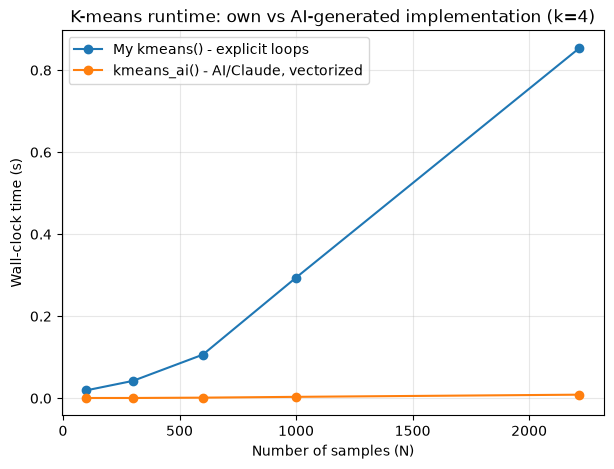

In [10]:
# --- A3 driver: performance comparison ---

feature_cols = ["Income", "Recency", "MntWines", "MntFruits", "MntMeatProducts",
                "MntFishProducts", "MntSweetProducts", "MntGoldProds",
                "NumDealsPurchases", "NumWebPurchases", "NumCatalogPurchases",
                "NumStorePurchases", "NumWebVisitsMonth"]

X_full = df[feature_cols].to_numpy(dtype=float)
X_full = (X_full - X_full.mean(axis=0)) / X_full.std(axis=0)

sample_sizes = [100, 300, 600, 1000, len(X_full)]
k = 4
rng = np.random.default_rng(0)
results = []

print(f"{'N':>6} | {'mine (s)':>10} | {'AI (s)':>10} | {'speedup':>8} | {'inertia match':>14}")
print("-" * 60)

for n in sample_sizes:
    idx = rng.choice(len(X_full), size=n, replace=False)
    X = X_full[idx]

    t0 = time.perf_counter()
    labels_mine, centroids_mine = kmeans(X, k=k, seed=1)
    t_mine = time.perf_counter() - t0

    t0 = time.perf_counter()
    labels_ai, centroids_ai = kmeans_ai(X, k=k, seed=1)
    t_ai = time.perf_counter() - t0

    inertia_mine = inertia(X, labels_mine, centroids_mine)
    inertia_ai = inertia(X, labels_ai, centroids_ai)
    match = "yes" if abs(inertia_mine - inertia_ai) < 1e-6 else "NO"
    speedup = t_mine / t_ai if t_ai > 0 else float("inf")
    results.append((n, t_mine, t_ai))

    print(f"{n:>6} | {t_mine:>10.4f} | {t_ai:>10.4f} | {speedup:>7.1f}x | {match:>14}")

ns = [r[0] for r in results]
mine_times = [r[1] for r in results]
ai_times = [r[2] for r in results]

plt.figure(figsize=(7,5))
plt.plot(ns, mine_times, marker="o", label="My kmeans() - explicit loops")
plt.plot(ns, ai_times, marker="o", label="kmeans_ai() - AI/Claude, vectorized")
plt.xlabel("Number of samples (N)"); plt.ylabel("Wall-clock time (s)")
plt.title("K-means runtime: own vs AI-generated implementation (k=4)")
plt.legend(); plt.grid(alpha=0.3)
plt.show()